<a href="https://colab.research.google.com/github/harithavijay11/harithavijay11/blob/main/Another_copy_of_Plotlycourse8week4.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#Plotly is a graphing library that helps you create interactive and visually appealing charts. Here, we're using Plotly Express (px), a high-level interface to Plotly that simplifies the process of creating charts.


#Examples:

**Bar Chart (px.bar):** Displays the sales by category.

**Line Chart (px.line):** Plots the sales trend over time, grouped by month.

**Pie Chart (px.pie):** Shows the sales distribution by category as a pie chart.

**Boxplot (px.box):** Displays the distribution of sales by category, highlighting the median, quartiles, and outliers.

**Conclusion:**
This code creates a simple interactive dashboard with Dash and Plotly, allowing users to filter and visualize sales data through multiple charts. Plotly is used for creating rich, interactive visualizations, while Dash provides the framework to build the web app.


#**Dash**

Dash is a powerful open-source Python framework for building interactive, web-based analytical applications without requiring JavaScript knowledge. It is built on top of Plotly for visualizations and Flask for web application functionality. Here's how you can get started with Dash

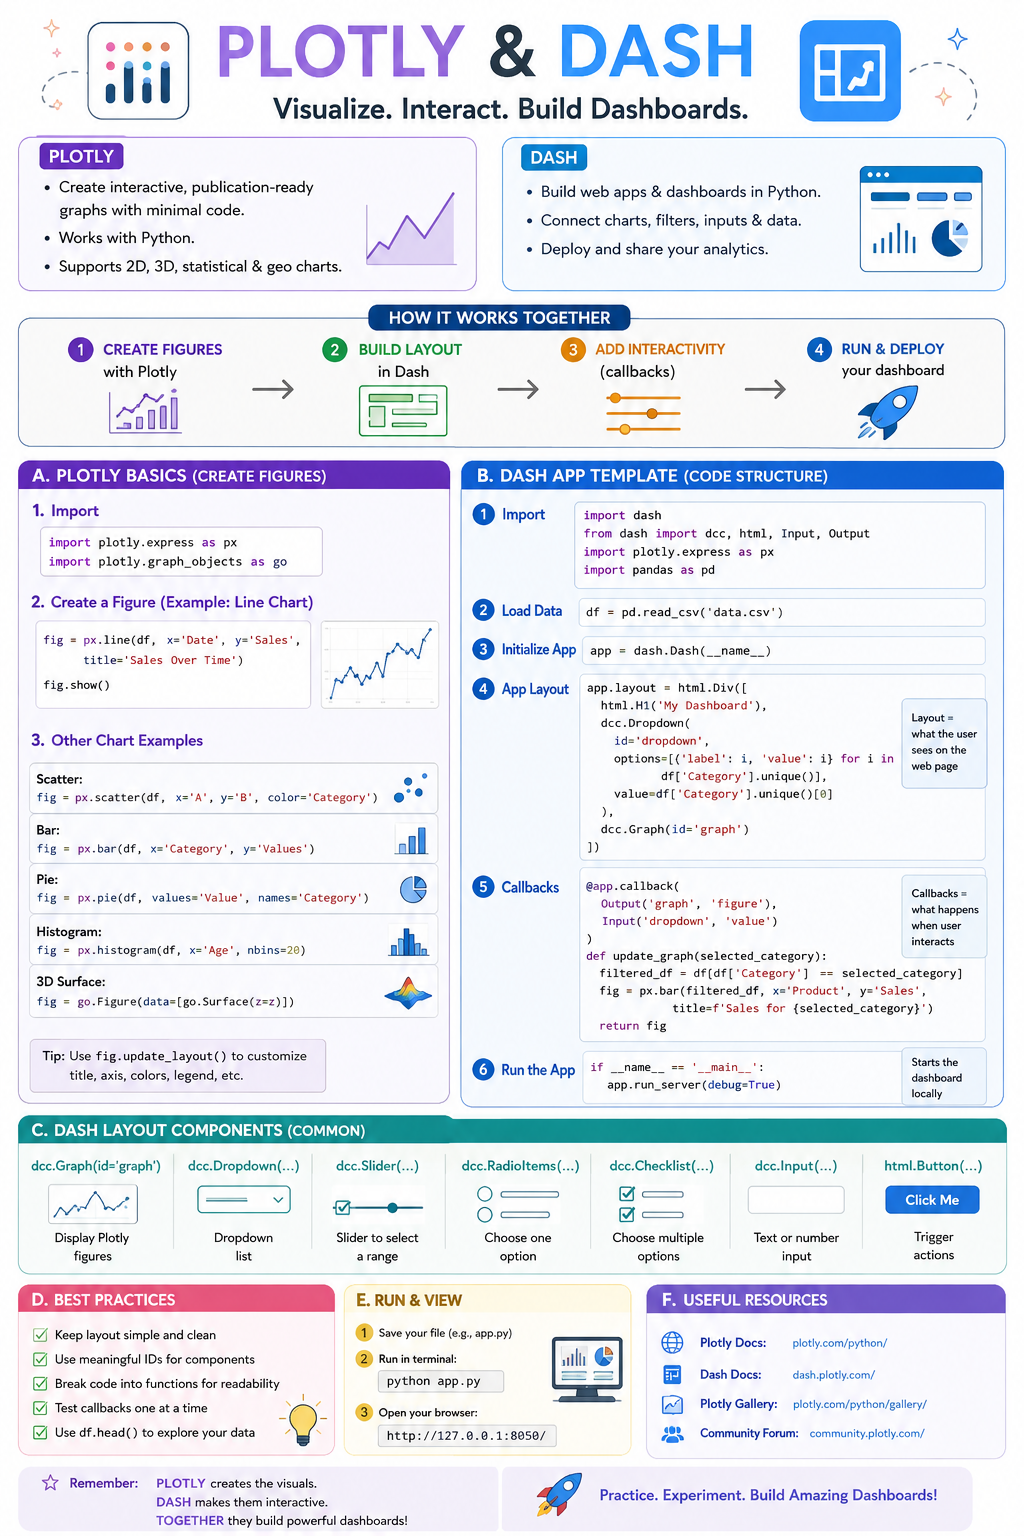

In [ ]:
from dash import Dash, dcc, html
import plotly.express as px

# 1. Create the Dash app
app = Dash(__name__)

# 2. Create a Plotly chart
df = px.data.iris()

fig = px.scatter(
    df,
    x="sepal_width",
    y="sepal_length",
    color="species"
)

# 3. Build the webpage
app.layout = html.Div([

    html.H1("My First Dash App"),

    html.P("Iris Flower Dashboard"),

    dcc.Graph(figure=fig)
])

# 4. Run the app
if __name__ == "__main__":
    app.run(debug=True, jupyter_mode="external")

Dash app running on:
Try `serve_kernel_port_as_iframe` instead. 


<IPython.core.display.Javascript object>

#Sales Performance Dashboard

Imagine you're a Data Analyst for a retail company. The manager wants to answer:

How much revenue did we generate?

Which region is performing best?

Which products are selling?

What happens when I select a different region?

Can I compare categories

In [ ]:
from dash import Dash, dcc, html, Input, Output
import plotly.express as px
import pandas as pd

data = {
    "Month": [
        "Jan", "Jan", "Jan", "Feb", "Feb", "Feb",
        "Mar", "Mar", "Mar", "Apr", "Apr", "Apr"
    ],

    "Region": [
        "East", "West", "Central",
        "East", "Central", "Central",
        "East", "West", "Central",
        "West", "West", "East"
    ],

    "Category": [
        "Technology", "Furniture", "Office Supplies",
        "Technology", "Furniture", "Office Supplies",
        "Technology", "Furniture", "Office Supplies",
        "Technology", "Furniture", "Office Supplies"
    ],

    "Sales": [
        25000, 18000, 12000,
        28000, 21000, 14000,
        32000, 24000, 16000,
        35000, 26000, 19000
    ],

    "Profit": [
        5000, 3000, 2500,
        6000, 3500, 2800,
        7000, 4200, 3200,
        8000, 4500, 3800
    ]
}

df = pd.DataFrame(data)
df

,Month,Region,Category,Sales,Profit
0,Jan,East,Technology,25000,5000
1,Jan,West,Furniture,18000,3000
2,Jan,Central,Office Supplies,12000,2500
3,Feb,East,Technology,28000,6000
4,Feb,Central,Furniture,21000,3500
5,Feb,Central,Office Supplies,14000,2800
6,Mar,East,Technology,32000,7000
7,Mar,West,Furniture,24000,4200
8,Mar,Central,Office Supplies,16000,3200
9,Apr,West,Technology,35000,8000


In [ ]:
from dash import Dash, dcc, html, Input, Output
import plotly.express as px
import pandas as pd

# Create the app
app = Dash(__name__)

# -------------------------
# LAYOUT
# -------------------------
app.layout = html.Div([

    html.H1("🛍️ Retail Sales Dashboard"),

    html.P(
        "Use the filters below to explore sales performance."
    ),

    # -------------------------
    # REGION DROPDOWN
    # -------------------------
    html.Label("Select Region:"),

    dcc.Dropdown(
        id="region_dropdown",

        options=[
            {"label": region, "value": region}
            for region in df["Region"].unique()
        ],

        value="East"
    ),

    html.Br(),

    # -------------------------
    # CATEGORY CHECKLIST
    # -------------------------
    html.Label("Select Categories:"),

    dcc.Checklist(
        id="category_checklist",

        options=[
            {"label": category, "value": category}
            for category in df["Category"].unique()
        ],

        value=list(df["Category"].unique()),

        inline=True
    ),

    html.Br(),

    # -------------------------
    # GRAPH
    # -------------------------
    dcc.Graph(
        id="sales_graph"
    )
])


# -------------------------
# CALLBACK
# -------------------------
@app.callback(

    Output(
        "sales_graph",
        "figure"
    ),

    Input(
        "region_dropdown",
        "value"
    ),

    Input(
        "category_checklist",
        "value"
    )
)

# -------------------------
# CALLBACK FUNCTION
# -------------------------
def update_dashboard(selected_region, selected_categories):

    # Filter by region
    filtered_df = df[
        df["Region"] == selected_region
    ]

    # Filter by selected categories
    filtered_df = filtered_df[
        filtered_df["Category"].isin(selected_categories)
    ]

    # Create Plotly chart
    fig = px.bar(
        filtered_df,
        x="Month",
        y="Sales",
        color="Category",
        barmode="group",
        title=f"Sales Performance — {selected_region}"
    )

    return fig


# -------------------------
# RUN APP
# -------------------------
if __name__ == "__main__":
    app.run(debug=True)

<IPython.core.display.Javascript object>

#app.callback

@app.callback(...): The callback decorator is used to link the input (dropdown) with the output (graphs). The callback function will be triggered whenever the user changes the selected year in the dropdown.

dash.Output(...): Specifies the output components (the graphs) that will be updated by the callback function. Each output corresponds to a specific graph in the layout.

dash.Input('year-filter', 'value'): This defines the input for the callback. Whenever the user selects a different year in the dropdown (year-filter), the callback function will be triggered.

update_charts(selected_year): The callback function that updates the charts based on the selected year.

filtered = df[df['Year'] == selected_year]: Filters the DataFrame to show data only for the selected year.

fig1 = px.bar(...): Creates a bar chart showing sales by category.

fig2 = px.line(...): Creates a line chart showing the sales trend by month.

fig3 = px.pie(...): Creates a pie chart showing the share of sales by category.

fig4 = px.box(...): Creates a boxplot showing the distribution of sales by category.

return fig1, fig2, fig3, fig4: Returns the figures (charts) that are displayed on the dashboard.

In [ ]:
import plotly.express as px
import pandas as pd

# Sample data
df = pd.DataFrame({
    "Region": ["North", "North", "South", "South", "East", "East"],
    "Category": ["Furniture", "Office Supplies", "Furniture", "Technology", "Technology", "Office Supplies"],
    "Sub-Category": ["Chairs", "Paper", "Tables", "Laptops", "Laptops", "Paper"],
    "Sales": [300, 150, 450, 700, 500, 200]
})

# Create a Sunburst chart
fig = px.sunburst(df, path=["Region", "Category", "Sub-Category"], values="Sales")

# Show the plot
fig.show()
